In [ ]:
# this mounts your Google Drive to the Colab VM.
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# enter the foldername in your Drive where you have saved the unzipped
# assignment folder, e.g. 'ece697ls/assignments/assignment3/'
FOLDERNAME = None
assert FOLDERNAME is not None, "[!] Enter the foldername."

# now that we've mounted your Drive, this ensures that
# the Python interpreter of the Colab VM can load
# python files from within it.
import sys
sys.path.append('/content/drive/My Drive/{}'.format(FOLDERNAME))

%cd /content

# Dropout
Dropout [1] is a technique for regularizing neural networks by randomly setting some output activations to zero during the forward pass. In this exercise you will implement a dropout layer and modify your fully-connected network to optionally use dropout.

[1] [Geoffrey E. Hinton et al, "Improving neural networks by preventing co-adaptation of feature detectors", arXiv 2012](https://arxiv.org/abs/1207.0580)

In [1]:
# As usual, a bit of setup
from __future__ import print_function
import time
import numpy as np
import matplotlib.pyplot as plt
from ece662.classifiers.fc_net import *
from ece662.data_utils import get_CINIC10_data
from ece662.gradient_check import eval_numerical_gradient, eval_numerical_gradient_array
from ece662.solver import Solver

%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

# for auto-reloading external modules
# see http://stackoverflow.com/questions/1907993/autoreload-of-modules-in-ipython
%load_ext autoreload
%autoreload 2

def rel_error(x, y):
  """ returns relative error """
  return np.max(np.abs(x - y) / (np.maximum(1e-8, np.abs(x) + np.abs(y))))

=========== You can safely ignore the message below if you are NOT working on ConvolutionalNetworks.ipynb ===========
	You will need to compile a Cython extension for a portion of this assignment.
	The instructions to do this will be given in a section of the notebook below.
	There will be an option for Colab users and another for Jupyter (local) users.


In [2]:
# Load the (preprocessed) CINIC10 data - Note that CINIC10 was modified in size for this course

data = get_CINIC10_data()
for k, v in list(data.items()):
  print(('%s: ' % k, v.shape))

print('Number of Classes: {}'.format(len(np.unique(data['y_train'])))) 

('X_train: ', (53973, 3, 32, 32))
('y_train: ', (53973,))
('X_val: ', (10195, 3, 32, 32))
('y_val: ', (10195,))
('X_test: ', (10196, 3, 32, 32))
('y_test: ', (10196,))
Number of Classes: 6


# Dropout forward pass
In the file `ece697ls/layers.py`, implement the forward pass for dropout. Since dropout behaves differently during training and testing, make sure to implement the operation for both modes.

Once you have done so, run the cell below to test your implementation.

In [3]:
np.random.seed(231)
x = np.random.randn(500, 500) + 10

for p in [0.25, 0.4, 0.7]:
  out, _ = dropout_forward(x, {'mode': 'train', 'p': p})
  out_test, _ = dropout_forward(x, {'mode': 'test', 'p': p})

  print('Running tests with p = ', p)
  print('Mean of input: ', x.mean())
  print('Mean of train-time output: ', out.mean())
  print('Mean of test-time output: ', out_test.mean())
  print('Fraction of train-time output set to zero: ', (out == 0).mean())
  print('Fraction of test-time output set to zero: ', (out_test == 0).mean())
  print()

Running tests with p =  0.25
Mean of input:  10.000207878477502
Mean of train-time output:  9.99819894778847
Mean of test-time output:  10.000207878477502
Fraction of train-time output set to zero:  0.250168
Fraction of test-time output set to zero:  0.0

Running tests with p =  0.4
Mean of input:  10.000207878477502
Mean of train-time output:  9.976910758765856
Mean of test-time output:  10.000207878477502
Fraction of train-time output set to zero:  0.401368
Fraction of test-time output set to zero:  0.0

Running tests with p =  0.7
Mean of input:  10.000207878477502
Mean of train-time output:  10.029131799886338
Mean of test-time output:  10.000207878477502
Fraction of train-time output set to zero:  0.69926
Fraction of test-time output set to zero:  0.0



# Dropout backward pass
In the file `ece697ls/layers.py`, implement the backward pass for dropout. After doing so, run the following cell to numerically gradient-check your implementation.

In [7]:
np.random.seed(231)
x = np.random.randn(10, 10) + 10
dout = np.random.randn(*x.shape)

dropout_param = {'mode': 'train', 'p': 0.2, 'seed': 123}
out, cache = dropout_forward(x, dropout_param)
dx = dropout_backward(dout, cache)
dx_num = eval_numerical_gradient_array(lambda xx: dropout_forward(xx, dropout_param)[0], x, dout)

# Error should be around e-10 or less
print('dx relative error: ', rel_error(dx, dx_num))

dx relative error:  1.892894523661062e-11


## Inline Question 1:
What happens if we do not divide the values being passed through inverse dropout by `p` in the dropout layer? Why does that happen?

## Answer:
If we do not divide by p, then during training the average output of each layer is scaled by 'p', (since only p of the outputs are kept and the rest are zeroed) which results in the model thinking that the activations from each layer are smaller than they should be. At test-time, when dropout isn't applied, the outputs of layers are thus technically scaled by 1/p. In order to avoid this, the factor of 'p' is removed during training time by multiplying the output with 1/p.

# Fully-connected nets with Dropout
In the file `ece697ls/classifiers/fc_net.py`, modify your implementation to use dropout. Specifically, if the constructor of the network receives a value that is not 1 for the `dropout` parameter, then the net should add a dropout layer immediately after every ReLU nonlinearity. After doing so, run the following to numerically gradient-check your implementation.

In [9]:
np.random.seed(231)
N, D, H1, H2, C = 2, 15, 20, 30, 10
X = np.random.randn(N, D)
y = np.random.randint(C, size=(N,))

for dropout in [1, 0.75, 0.5]:
  print('Running check with dropout = ', dropout)
  model = FullyConnectedNet([H1, H2], input_dim=D, num_classes=C,
                            weight_scale=5e-2, dtype=np.float64,
                            dropout=dropout, seed=123)

  loss, grads = model.loss(X, y)
  print('Initial loss: ', loss)
  
  # Relative errors should be around e-6 or less; Note that it's fine
  # if for dropout=1 you have W2 error be on the order of e-5.
  for name in sorted(grads):
    f = lambda _: model.loss(X, y)[0]
    grad_num = eval_numerical_gradient(f, model.params[name], verbose=False, h=1e-5)
    print('%s relative error: %.2e' % (name, rel_error(grad_num, grads[name])))
  print()

Running check with dropout =  1
Initial loss:  2.3004790897684924
W1 relative error: 1.48e-07
W2 relative error: 2.21e-05
W3 relative error: 3.53e-07
b1 relative error: 5.38e-09
b2 relative error: 2.09e-09
b3 relative error: 5.80e-11

Running check with dropout =  0.75
Initial loss:  2.302371489704412
W1 relative error: 2.20e-07
W2 relative error: 4.74e-06
W3 relative error: 2.60e-08
b1 relative error: 3.45e-08
b2 relative error: 1.67e-08
b3 relative error: 1.70e-10

Running check with dropout =  0.5
Initial loss:  2.310136908722148
W1 relative error: 2.57e-08
W2 relative error: 1.49e-08
W3 relative error: 4.49e-08
b1 relative error: 1.35e-09
b2 relative error: 1.91e-09
b3 relative error: 9.51e-11



# Regularization experiment
As an experiment, we will train a pair of two-layer networks on 500 training examples: one will use no dropout, and one will use a keep probability of 0.25. We will then visualize the training and validation accuracies of the two networks over time.

In [21]:
# Train two identical nets, one with dropout and one without
np.random.seed(231)
num_train = 500
small_data = {
  'X_train': data['X_train'][:num_train],
  'y_train': data['y_train'][:num_train],
  'X_val': data['X_val'],
  'y_val': data['y_val'],
}

solvers = {}
dropout_choices = [1, 0.25] # added 0.5, 0.15, 0.1
for dropout in dropout_choices:
  model = FullyConnectedNet([500], dropout=dropout, num_classes=6) #added normalization=batchnorm
  print(dropout)
  # epochs from 10->20, batchsize 100->150, lr 5e-4 -> 1e-3
  solver = Solver(model, small_data,
                  num_epochs=10, batch_size=100,
                  update_rule='adam',
                  optim_config={
                    'learning_rate': 5e-4,
                  },
                  verbose=True, print_every=100)
  solver.train()
  solvers[dropout] = solver
  print()

1
(Iteration 1 / 100) loss: 1.787314
(Epoch 0 / 20) train acc: 0.276000; val_acc: 0.217460
(Epoch 1 / 20) train acc: 0.424000; val_acc: 0.254340
(Epoch 2 / 20) train acc: 0.480000; val_acc: 0.274252
(Epoch 3 / 20) train acc: 0.522000; val_acc: 0.285924
(Epoch 4 / 20) train acc: 0.596000; val_acc: 0.292594
(Epoch 5 / 20) train acc: 0.656000; val_acc: 0.297989
(Epoch 6 / 20) train acc: 0.722000; val_acc: 0.292202
(Epoch 7 / 20) train acc: 0.794000; val_acc: 0.279745
(Epoch 8 / 20) train acc: 0.800000; val_acc: 0.264247
(Epoch 9 / 20) train acc: 0.856000; val_acc: 0.269544
(Epoch 10 / 20) train acc: 0.922000; val_acc: 0.271506
(Epoch 11 / 20) train acc: 0.922000; val_acc: 0.277489
(Epoch 12 / 20) train acc: 0.932000; val_acc: 0.275429
(Epoch 13 / 20) train acc: 0.960000; val_acc: 0.264541
(Epoch 14 / 20) train acc: 0.970000; val_acc: 0.271113
(Epoch 15 / 20) train acc: 0.984000; val_acc: 0.269838
(Epoch 16 / 20) train acc: 0.978000; val_acc: 0.251888
(Epoch 17 / 20) train acc: 0.996000; v

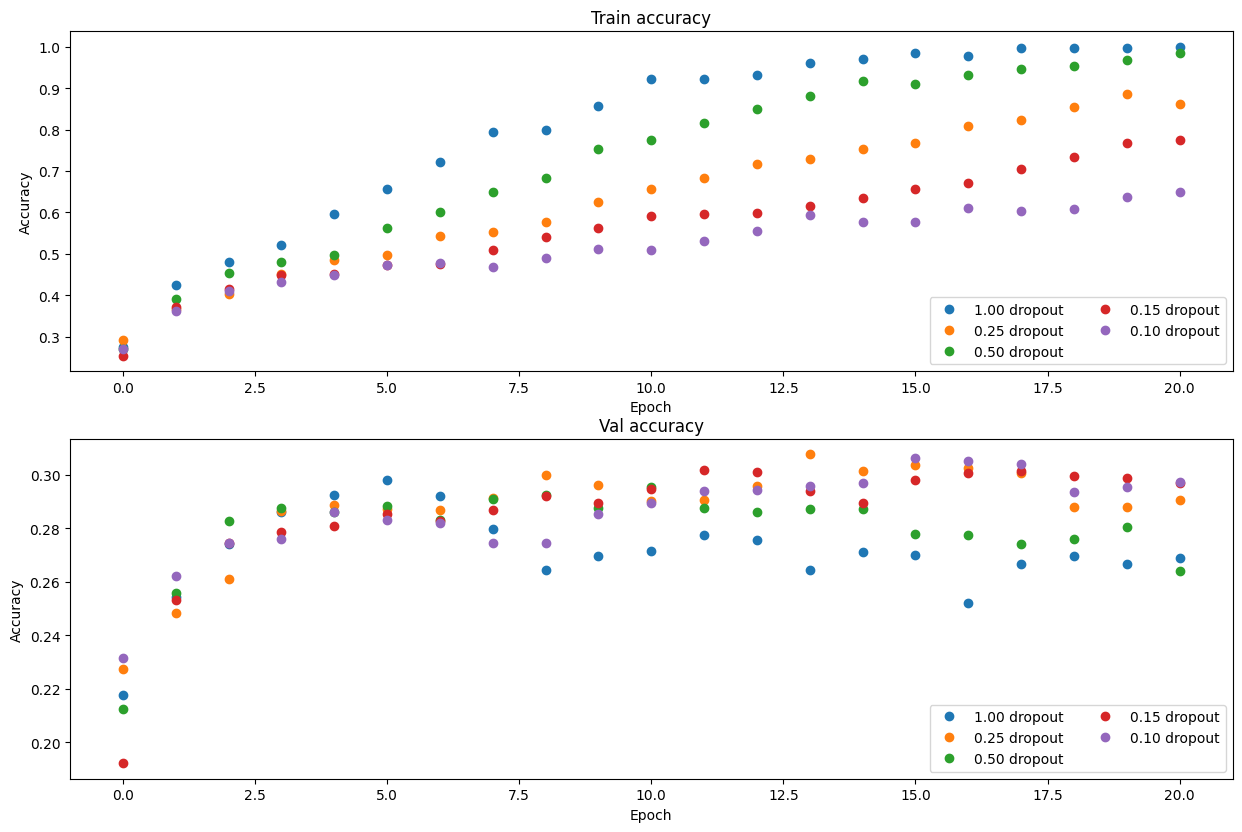

In [22]:
# Plot train and validation accuracies of the two models

train_accs = []
val_accs = []
for dropout in dropout_choices:
  solver = solvers[dropout]
  train_accs.append(solver.train_acc_history[-1])
  val_accs.append(solver.val_acc_history[-1])

plt.subplot(3, 1, 1)
for dropout in dropout_choices:
  plt.plot(solvers[dropout].train_acc_history, 'o', label='%.2f dropout' % dropout)
plt.title('Train accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(ncol=2, loc='lower right')
  
plt.subplot(3, 1, 2)
for dropout in dropout_choices:
  plt.plot(solvers[dropout].val_acc_history, 'o', label='%.2f dropout' % dropout)
plt.title('Val accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(ncol=2, loc='lower right')

plt.gcf().set_size_inches(15, 15)
plt.show()

## Inline Question 2:
Compare the validation and training accuracies with and without dropout -- what do your results suggest about dropout as a regularizer?

## Answer:
Dropout seems to be an effective regularizer, as while it causes lower training accuracy, it causes superior validation accuracy. This makes sense, considering what dropout does, which is periodically disable certain neurons which encourages the model to learn a distribution of patterns rather than becoming overreliant on one particular set of neurons. In essence, it encourages the model to use all of its neurons to learn a pattern rather than just a few because the model will never have access to all of its neurons. Since it cannot simply focus on training a few neurons, it has to train all its neurons, and distribute its ability to make predictions across all its neurons.

## Inline Question 3:
Suppose we are training a deep fully-connected network for image classification, with dropout after hidden layers (parameterized by keep probability p). If we are concerned about overfitting, how should we modify p (if at all) when we decide to decrease the size of the hidden layers (that is, the number of nodes in each layer)?

## Answer:
If you're concerned about overfitting, decreasing the size of the hidden layers will already prevent overfitting by impeding the model's ability to construct a "perfect model". Depending on how much the hidden layer size is decreased by, it may be prudent to leave p unchanged, or even to increase the value of p to compensate for the loss of neurons, even though decreasing p usually also decreases overfitting. 